# Day 5 — Portfolio Optimization (Markowitz MVO + Black-Litterman)

**Goal**: Instead of naive equal-weighting (10% per stock), use Modern Portfolio Theory to find the mathematically optimal capital allocation.

## 1. Markowitz Mean-Variance Optimization (MVO)
- Uses historical returns and Ledoit-Wolf shrunk covariance matrix to construct the **Efficient Frontier**.
- We will find the **Maximum Sharpe** (Tangency) portfolio and the **Minimum Volatility** portfolio.

## 2. Black-Litterman Model
- MVO is notoriously "error-maximizing" — tiny changes in historical returns cause massive shifts in target weights.
- Black-Litterman solves this by starting with **market-implied returns** (the prior) and updating them using **subjective views** (the posterior) using Bayesian logic.
- We will inject an AI/Alpha view on specific stocks and re-run the optimizer.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

print('Environment ready ✓')

Environment ready ✓


## 1. Load Data

In [2]:
from src.data.loader import DataLoader

loader = DataLoader()
raw_data = loader.load(force_download=False)

# Extract Close prices into a single T x N DataFrame
close_prices = pd.DataFrame({t: df['Close'] for t, df in raw_data.items()}).dropna()
print(f'Price matrix shape: {close_prices.shape}')

23:39:57 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31


23:39:57 | INFO | DataLoader |   AAPL   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


23:39:57 | INFO | DataLoader |   MSFT   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


23:39:57 | INFO | DataLoader |   GOOGL  — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


23:39:57 | INFO | DataLoader |   AMZN   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


...

23:39:57 | INFO | DataLoader |   JNJ    — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_JNJ.csv


23:39:57 | INFO | DataLoader |   TSLA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_TSLA.csv


23:39:57 | INFO | DataLoader |   NVDA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_NVDA.csv



23:39:57 | INFO | DataLoader | Loaded 10 / 10 tickers successfully.


Price matrix shape: (1760, 10)


## 2. Markowitz MVO (Historical)

In [3]:
from src.portfolio.markowitz import MarkowitzOptimizer

opt = MarkowitzOptimizer(close_prices)
opt.fit(returns_method='mean_historical')

# 1. Max Sharpe Portfolio (Tangency)
w_sharpe = opt.max_sharpe()
perf_sharpe = opt.portfolio_performance(w_sharpe)

# 2. Min Volatility Portfolio
w_minvol = opt.min_volatility()
perf_minvol = opt.portfolio_performance(w_minvol)

# 3. Naive Equal Weight (Benchmark)
w_equal = opt.equal_weights()
perf_equal = opt.portfolio_performance(w_equal)

print('\n=== Portfolio Performance (Historical Expected) ===')
print(f"Max Sharpe: Ret={perf_sharpe['Expected Return (%)']:5.1f}% | Vol={perf_sharpe['Expected Volatility (%)']:4.1f}% | Sharpe={perf_sharpe['Sharpe Ratio']:.2f}")
print(f"Min Vol   : Ret={perf_minvol['Expected Return (%)']:5.1f}% | Vol={perf_minvol['Expected Volatility (%)']:4.1f}% | Sharpe={perf_minvol['Sharpe Ratio']:.2f}")
print(f"Equal Wt  : Ret={perf_equal['Expected Return (%)']:5.1f}% | Vol={perf_equal['Expected Volatility (%)']:4.1f}% | Sharpe={perf_equal['Sharpe Ratio']:.2f}")

23:39:58 | INFO | MarkowitzOptimizer | Fitting Markowitz optimizer …


23:39:58 | INFO | MarkowitzOptimizer | Expected returns (top 3): {'NVDA': 0.6109, 'TSLA': 0.5308, 'AAPL': 0.2994}


23:39:58 | INFO | MarkowitzOptimizer | Covariance matrix shape: (10, 10)


23:39:58 | INFO | MarkowitzOptimizer | Max Sharpe: Return=46.34%  Vol=36.68%  Sharpe=1.154


23:39:58 | INFO | MarkowitzOptimizer | Min Volatility: Return=11.63%  Vol=18.39%  Sharpe=0.632



=== Portfolio Performance (Historical Expected) ===
Max Sharpe: Ret= 46.3% | Vol=36.7% | Sharpe=1.15
Min Vol   : Ret= 11.6% | Vol=18.4% | Sharpe=0.41
Equal Wt  : Ret= 24.7% | Vol=24.4% | Sharpe=0.85


## 3. Visualise the Efficient Frontier

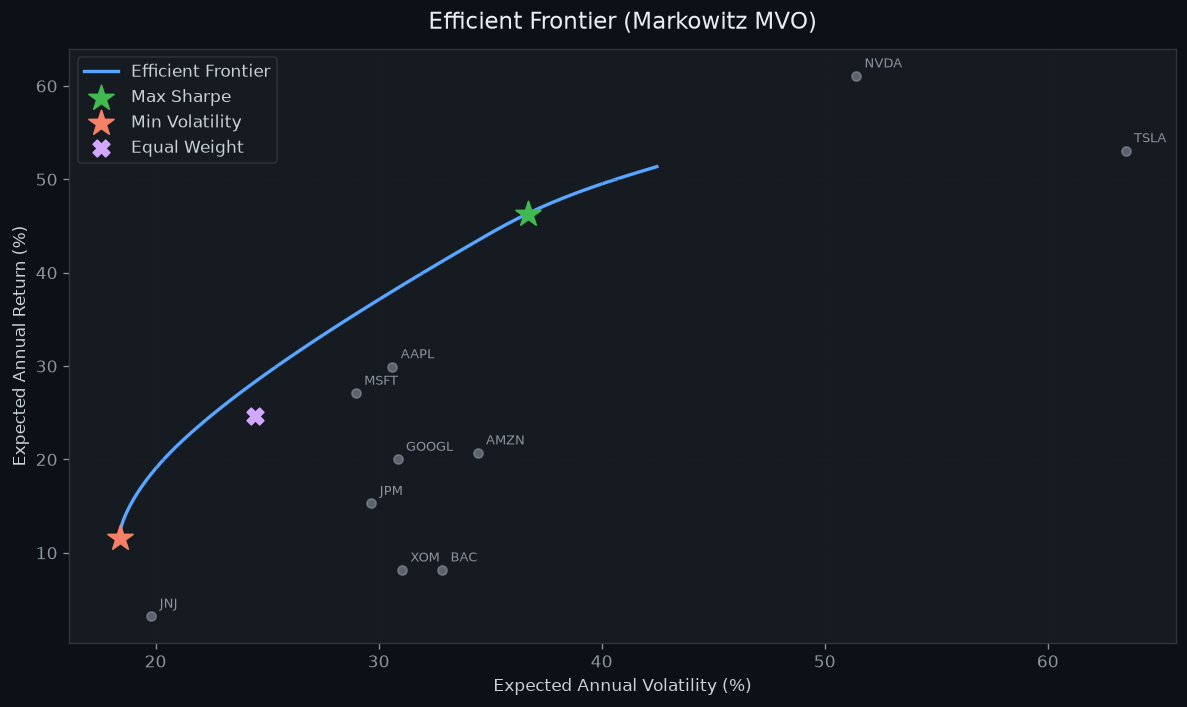

Saved → reports/day5_efficient_frontier.png


In [4]:
frontier_df = opt.efficient_frontier_points(n_points=100)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot frontier
ax.plot(frontier_df['Volatility (%)'], frontier_df['Return (%)'],
        color='#58a6ff', lw=2, label='Efficient Frontier', zorder=1)

# Plot individual assets
ann_ret = opt.mu * 100
ann_vol = pd.Series(np.diag(opt.S)**0.5, index=opt.S.index) * 100
ax.scatter(ann_vol, ann_ret, marker='o', color='#8b949e', s=30, alpha=0.6, zorder=2)
for t in opt.tickers:
    ax.annotate(t, (ann_vol[t], ann_ret[t]), textcoords='offset points', xytext=(5,5),
                fontsize=8, color='#8b949e')

# Plot optimal portfolios
ax.scatter(perf_sharpe['Expected Volatility (%)'], perf_sharpe['Expected Return (%)'],
           marker='*', color='#3fb950', s=250, zorder=3, label='Max Sharpe')
ax.scatter(perf_minvol['Expected Volatility (%)'], perf_minvol['Expected Return (%)'],
           marker='*', color='#f78166', s=250, zorder=3, label='Min Volatility')
ax.scatter(perf_equal['Expected Volatility (%)'], perf_equal['Expected Return (%)'],
           marker='X', color='#d2a8ff', s=100, zorder=3, label='Equal Weight')

ax.set_title('Efficient Frontier (Markowitz MVO)', fontsize=14, color='#e6edf3', pad=12)
ax.set_xlabel('Expected Annual Volatility (%)')
ax.set_ylabel('Expected Annual Return (%)')
ax.legend(fontsize=10, facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../reports/day5_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day5_efficient_frontier.png')

## 4. Black-Litterman Setup

In [5]:
from src.portfolio.black_litterman import BlackLittermanOptimizer

# Approximate relative market cap weights (Dec 2024 order of magnitude)
mcaps = {
    'AAPL':  3.0,
    'MSFT':  2.9,
    'NVDA':  2.2,
    'GOOGL': 1.8,
    'AMZN':  1.5,
    'TSLA':  0.6,
    'JPM':   0.5,
    'XOM':   0.4,
    'JNJ':   0.3,
    'BAC':   0.2,
}

bl = BlackLittermanOptimizer(close_prices, mcaps)
prior_ret = bl.get_prior_returns()

print('=== Market-Implied Prior Returns ===')
print((prior_ret * 100).round(2).sort_values(ascending=False))

23:40:00 | INFO | BlackLitterman | Market-implied risk aversion (delta): 2.500


=== Market-Implied Prior Returns ===
NVDA     29.93
TSLA     25.26
AMZN     18.66
AAPL     18.04
MSFT     17.93
GOOGL    17.47
BAC      11.81
JPM      10.63
XOM       7.60
JNJ       4.80
dtype: float64


## 5. Injecting Subjective Views
Assume our algorithm predicts a tech rally led by AI, but weakness in legacy tech/auto.

In [6]:
# Absolute views on expected annual return
views = {
    'NVDA': 0.45,   # Highly bullish on AI chips
    'MSFT': 0.25,   # Bullish on cloud AI
    'TSLA': 0.05,   # Bearish/neutral on auto margins
    'AAPL': 0.10,   # Moderate view
}

# Confidence matrix (0 to 1)
confidences = [0.90, 0.70, 0.60, 0.40]

bl_ret = bl.compute_bl_returns(views, confidences=confidences)
bl_cov = bl.get_posterior_cov()

print('\n=== BL Posterior Returns (Prior + Views) ===')
print((bl_ret * 100).round(2).sort_values(ascending=False))

23:40:00 | INFO | BlackLitterman | Computing Black-Litterman posterior returns …


23:40:00 | INFO | BlackLitterman | Highest BL Returns: {'NVDA': 0.429, 'MSFT': 0.2274, 'AMZN': 0.2243}



=== BL Posterior Returns (Prior + Views) ===
NVDA     42.90
MSFT     22.74
AMZN     22.43
GOOGL    21.18
AAPL     18.90
TSLA     16.89
BAC      13.32
JPM      12.11
XOM       8.37
JNJ       5.50
dtype: float64


## 6. Run MVO with Black-Litterman Inputs

In [7]:
opt_bl = MarkowitzOptimizer(close_prices)
opt_bl.fit()

# Override with BL posterior estimates
opt_bl.mu = bl_ret
opt_bl.S  = bl_cov

w_bl = opt_bl.max_sharpe()
perf_bl = opt_bl.portfolio_performance(w_bl)

print('\n=== BL-MVO Max Sharpe Performance ===')
print(f"Ret={perf_bl['Expected Return (%)']:5.1f}% | Vol={perf_bl['Expected Volatility (%)']:4.1f}% | Sharpe={perf_bl['Sharpe Ratio']:.2f}")

23:40:00 | INFO | MarkowitzOptimizer | Fitting Markowitz optimizer …


23:40:00 | INFO | MarkowitzOptimizer | Expected returns (top 3): {'NVDA': 0.6109, 'TSLA': 0.5308, 'AAPL': 0.2994}


23:40:00 | INFO | MarkowitzOptimizer | Covariance matrix shape: (10, 10)


23:40:00 | INFO | MarkowitzOptimizer | Max Sharpe: Return=30.58%  Vol=34.24%  Sharpe=0.776



=== BL-MVO Max Sharpe Performance ===
Ret= 30.6% | Vol=34.2% | Sharpe=0.78


## 7. Weight Comparison Heatmap

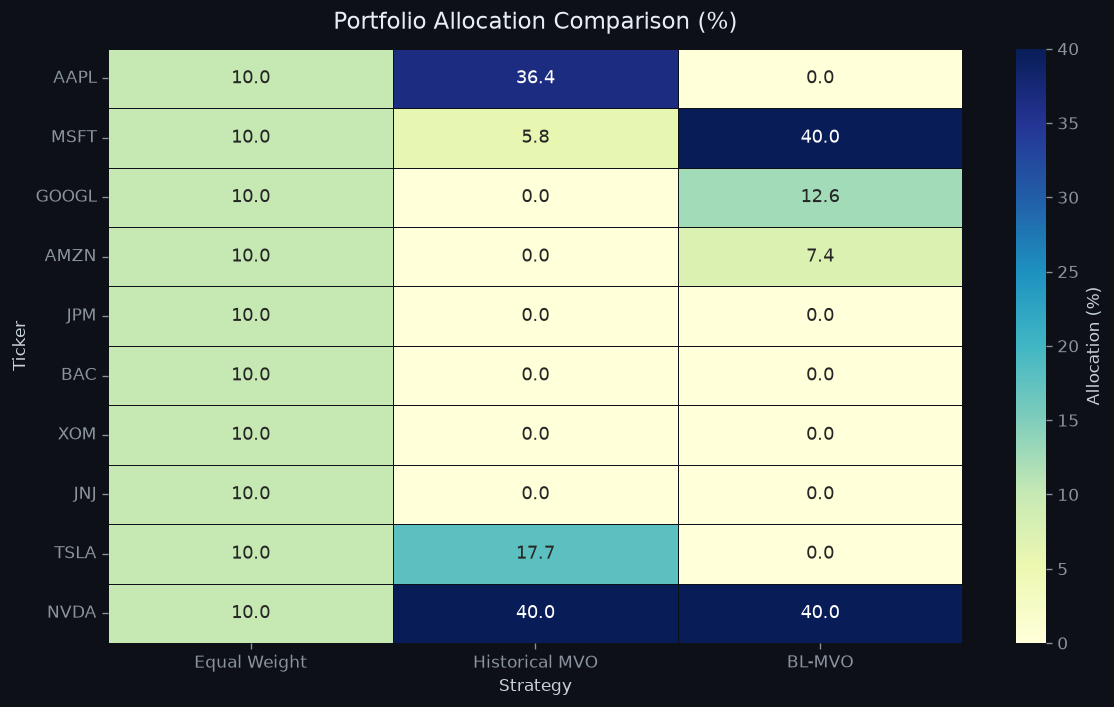

Saved → reports/day5_allocation_heatmap.png


In [8]:
weights_df = pd.DataFrame({
    'Equal Weight':   w_equal,
    'Historical MVO': w_sharpe,
    'BL-MVO':         w_bl,
}).fillna(0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(weights_df, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size': 11}, ax=ax,
            cbar_kws={'label': 'Allocation (%)'})

ax.set_title('Portfolio Allocation Comparison (%)', fontsize=14, color='#e6edf3', pad=12)
ax.set_ylabel('Ticker')
ax.set_xlabel('Strategy')
plt.tight_layout()
fig.savefig('../reports/day5_allocation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day5_allocation_heatmap.png')

## 8. Export Target Weights

In [9]:
out_dir = Path('../data/portfolio')
out_dir.mkdir(exist_ok=True)

weights_df.to_csv(out_dir / 'target_weights.csv')
print('Saved → data/portfolio/target_weights.csv')

print('\n✅ Day 5 Complete')

Saved → data/portfolio/target_weights.csv

✅ Day 5 Complete
